# LLM Inference & Optimization

![random](../_asset/images/random.jpg)

One of the perks of working at ThoughtWorks is being surrounded by very smart people who constantly keep you on your toes—and never let you stop learning. One such colleague recently triggered some thoughts about inference optimizations, which led me to explore and write a few things down to connect the dots.

>_BTW, the image above is just a random output from a diffusion model and has absolutely nothing to do with inference optimization. I added it just to reflect the state of my mind—with so many AI concepts floating around—everything starts to make sense... and then in the next [moment](https://n03an.me/moment.html), it doesn’t._ 😉

> ⚠️ [note] the flow of this notebook is more on understanding the inference pipeline using an example of decoder transformer model like LLaMA 2, and appreciating the memory and computation requirements demanding the need for optimization. I will write down each optimization techniques in seperate notebooks later, and link them here...

## LLM Inference
So, what the heck is Inference??? Inference is an end to end flow of executing a forward pass through a pre-trained large language model (LLM) to generate an output from a given input sequence. This involves processing the input into tokens, applying the model’s fixed parameters (learned during training) to transform input tokens into contextually relevant output tokens. Now this is way too simplified definition for the inference - lets continue to double click...

![inference](../_asset/inference/basic.gif)

The End to End pipeline of LLM Inference can conceptualized as Input → Tokenization → Embedding → Prefill → Transformer Decoding / Generation → Output.

![pipeline](../_asset/inference/pipeline.png)

Will be too much to get into GPU Architecture - but just for my own curiosity, here is the brief on where on GPU the parameters are stored, KV is cached and where the tensor compute happens.

**GDDR (Graphics Double Data Rate) / VRAM memory** is used as the global memory for the GPU to store model weights, activations, and KV caches for LLM inference.

**SMs (Streaming Multiprocessors)** is the compute units that execute matrix multiplications, attention, softmax, etc. It consists of specialized units for fast matrix multiplies (used heavily in transformer layers) called as **Tensor Cores**

![gpu](../_asset/inference/gpu.png)

ref: [glossary](https://modal.com/gpu-glossary/readme) & [basic](https://www.cudocompute.com/blog/a-beginners-guide-to-nvidia-gpus)


## Attention Is All You Need
Such a "great" way to kill your sunday reading these "great" papers on [Attention Is All You Need](https://arxiv.org/pdf/1706.03762) and [Llama 2](https://arxiv.org/pdf/2307.09288) to understand inference on a decoder only transformer model like **LLaMA 2 7B**.

To make easier, lets assume that each word in the input sequence is a single token i.e. 
```
**PROMPT** 
Why there is always so much to learn?
```
is tokenized into 8 tokens with ID's: 
```
[2993, 1011, 318, 6717, 1121, 632, 311, 13779]
```

#### for **🦙 LLaMA 2 7B**:

* **$N = 8$**: Number of input tokens from `Why there is always so much to learn?`
* **$d_{model}$**: Hidden size = 4096 i.e. its dimensionality size
    - Dimensionality of the embeddings used throughout the model
    - Every token is represented as a vector of 4096 dimensions inside the model
    - All linear layers (Q/K/V projections, MLPs) operate on this dimensionality
* **$h$**: Number of attention heads = 32
* **$d_q = d_k = d_v$**: Dimensions of each **Query**, **Key** and **Value** vector per head

$$
d_q = d_k = d_v = \frac{d_{\text{model}}}{h} = \frac{4096}{32} = 128
$$

This means:
- Each of the **32 attention heads** operates on **128-dimensional** query, key, and value vectors.
- All heads run in parallel, and their outputs are concatenated to form a vector of size **4096** again:

$$
\text{Concat}(32 \times 128) = 4096
$$

![transformer](../_asset/inference/transformer.png)

<h3 style="background-color:#d1edff; padding:10px; border-radius:6px;">
1. Token Embedding Lookup
</h3>

Each token ID is mapped to a 4096-d vector via embedding table:

$$
X = E_{token}[t_1, t_2, ..., t_8] \quad \text{where } E_{token} \in \mathbb{R}^{V \times d_{model}}
$$

with $V$ = vocab size (e.g. 32000+) for LLaMA 2 7B.

**Shape**:

$$
X \in \mathbb{R}^{8 \times 4096}
$$

```python
X = token_embedding[input_ids]  # Shape: [8, 4096]
```

![embed](../_asset/inference/embed.gif)

<h3 style="background-color:#d1edff; padding:10px; border-radius:6px;">
2. LayerNorm - Pre-Attention
</h3>

Performed typically before attention or MLP in transformer architecture. Why???
- It stabilizes training (i.e. ensures consistent scaling) and helps avoid exploding/vanishing gradients.
- Helps improve convergence i.e. allows better optimization with gradient descent.

**LayerNorm 1 i.e. Pre-Attention**: $\text{LN}_1(X) \in \mathbb{R}^{8 \times 4096}$ is given by:

$$
\text{LN}_1(X)_i = \frac{X_i - \mu_i}{\sqrt{\sigma_i^2 + \epsilon}} \cdot \gamma + \beta, \quad \text{for } i = 1, \dots, 8
$$

Or more compactly for the full matrix:

$$
\text{LN}_1(X) = \frac{X - \mu}{\sqrt{\sigma^2 + \epsilon}} \cdot \gamma + \beta
$$

with:

* $X \in \mathbb{R}^{8 \times 4096}$ — the input matrix.
* $X_i \in \mathbb{R}^{4096}$ — the **i-th row** of $X$, i.e., one token embedding.
* $\mu_i = \frac{1}{4096} \sum_{j=1}^{4096} X_{ij}$ — mean of the features for token $i$.
* $\sigma_i^2 = \frac{1}{4096} \sum_{j=1}^{4096} (X_{ij} - \mu_i)^2$ — variance of the features.
* $\gamma \in \mathbb{R}^{4096}$ — Models learned scaling paramete... Learns how much to scale each feature
* $\beta \in \mathbb{R}^{4096}$ — Models learned shifting parameter.... Learns how much to shift each feature
* $\epsilon$ = small constant for numerical stability (e.g., $1e-6$) e.g. allows safe division by zero

**Shape**:
Output shape remains the same i.e. $X_{norm} = X = [8, 4096]$

<h3 style="background-color:#d1edff; padding:10px; border-radius:6px;">
3. Linear Projections for Q/K/V vectors
</h3>

In the [**attention mechanism**](https://arxiv.org/pdf/1706.03762), each input token is projected into three different vector spaces
* **Q = Query** i.e. What this token is looking for
* **K = Key** i.e. What other tokens contain
* **V = Value** i.e. The actual content/information
These determine **how much attention each token should pay to the others**



#### for **🦙 LLaMA 2 7B** the pre-trained $Q_{weights}$, $K_{weights}$, $V_{weights}$ would be

$Q_{weights}$ = $W_Q \in \mathbb{R}^{4096 \times 4096}$

* Learned matrix to project each token’s embedding into a **query vector**.
* Tells the model *what the token is querying for* in the context.

$K_{weights}$ = $W_K \in \mathbb{R}^{4096 \times 4096}$

* Learned matrix to project the token into a **key vector**.
* Encodes *what each token offers* or *matches* when compared with queries.

$V_{weights}$ = $W_V \in \mathbb{R}^{4096 \times 4096}$

* Learned matrix to produce the **value vector** from each token.
* Holds the actual content/information to be passed along after attention is calculated.


So...lets compute
#### $Q_{vector}$,$K_{vector}$, and $V_{vector}$

$$
Q_{\text{vector}} = X_{\text{norm}} \cdot W_Q
$$

$$
K_{\text{vector}} = X_{\text{norm}} \cdot W_K
$$

$$
V_{\text{vector}} = X_{\text{norm}} \cdot W_V
$$

Where:
* $X_{\text{norm}} = \text{LN}_1(X) \in \mathbb{R}^{8 \times 4096}$
* $W_Q, W_K, W_V \in \mathbb{R}^{4096 \times 4096}$ — learned projection weight matrices.

**Shape**:
Output shape  $Q_{\text{vector}}, K_{\text{vector}}, V_{\text{vector}} \in \mathbb{R}^{8 \times 4096} = [8, 4096]$


> ⚠️ [note] **🦙 LLaMA 2 7B** operates on 32 heads in each transformer layer (iteration). Each of the **32 attention heads** operates on **128-dimensional** query, key, and value vectors i.e. the Dimensionality **4096** is divided across the heads

#### **Head Splitting (reshape)**

Split the 4096-dimensional vectors into 32 heads of size 128:

$$
Q_{\text{split}} = \text{reshape}(Q_{\text{vector}}, [8, 32, 128]) \quad \in \mathbb{R}^{8 \times 32 \times 128}
$$

$$
K_{\text{split}} = \text{reshape}(K_{\text{vector}}, [8, 32, 128]) \quad \in \mathbb{R}^{8 \times 32 \times 128}
$$

$$
V_{\text{split}} = \text{reshape}(V_{\text{vector}}, [8, 32, 128]) \quad \in \mathbb{R}^{8 \times 32 \times 128}
$$


#### **Transpose for Multi-Head Attention**

Transpose the axes to move heads to the first dimension:

$$
Q_{\text{head}} = \text{transpose}(Q_{\text{split}}, (1, 0, 2)) \quad \in \mathbb{R}^{32 \times 8 \times 128}
$$

$$
K_{\text{head}} = \text{transpose}(K_{\text{split}}, (1, 0, 2)) \quad \in \mathbb{R}^{32 \times 8 \times 128}
$$

$$
V_{\text{head}} = \text{transpose}(V_{\text{split}}, (1, 0, 2)) \quad \in \mathbb{R}^{32 \times 8 \times 128}
$$


![qkv](../_asset/inference/qkv.gif)

<h3 style="background-color:#d1edff; padding:10px; border-radius:6px;">
4. Multi-Head Attention
</h3>

> ⚠️ [TODO] Self attention in itself needs a separate detail explanation... for e.g. for models like LLaMA 2, during self-attention the upper triangle of the tensor is masked -- for preserving the causal (autoregressive) property of the model... Its much more than that - will double click later... for now, will keep it brief...

#### ⚫️ 4a. Attention Score Matrix



The attention score matrix measures how much each token should pay attention to every other token in the sequence.

$$
\text{Scores}_{\text{head}} = \frac{Q_{\text{head}} \cdot K_{\text{head}}^\top}{\sqrt{d_k}}
$$

Where:

* $Q_{\text{head}}, K_{\text{head}} \in \mathbb{R}^{32 \times 8 \times 128}$
* For each head: compute dot product between **queries** and **keys** for all tokens
* $d_k = 128$ is the head dimension — we scale by $\sqrt{d_k}$ to stabilize gradients

* For each head and each token:
  * It compares the **query vector** of that token with the **key vectors** of all tokens in the sequence
  * Produces a **similarity score** — high score means: “I’m interested in this token”

i.e. For each head (32 total), compute dot products between all pairs of tokens (8 queries × 8 keys).

$$
\text{Scores}_{\text{head}}[h] = \frac{Q_{\text{head}}[h] \cdot K_{\text{head}}[h]^\top}{\sqrt{128}} \quad \in \mathbb{R}^{8 \times 8}
$$

**Shape**:

$$
\text{Scores}_{\text{head}} \in \mathbb{R}^{32 \times 8 \times 8}
$$

#### ⚫️ 4b. Apply Softmax to Attention Score Matrix

Once we have raw attention scores, we apply softmax across the last dimension. This is required because 
a. Raw scores can be negative, unbounded, or skewed
b. Softmax turns them into probabilities — i.e., values between 0 and 1 that sum to 1 across the sequence

$$
\text{Weights}_{\text{head}} = \text{softmax}(\text{Scores}_{\text{head}}, \text{dim} = -1)
$$

This ensures that for each query token, the weights across all keys sum to 1.

#### ⚫️ 4c. Compute Attention Output (Weighted Values)

This step is the heart of the attention mechanism. It determines what each token should actually "see" or focus on — by combining information from other tokens based on attention scores.

$$
\text{Output}_{\text{head}} = \text{Weights}_{\text{head}} \cdot V_{\text{head}}
$$

**Shape**:

* $\text{Weights}_{\text{head}} \in \mathbb{R}^{32 \times 8 \times 8}$
* $V_{\text{head}} \in \mathbb{R}^{32 \times 8 \times 128}$

Dot product over the second dimension (sequence length) gives:

$$
\text{Output}_{\text{head}} \in \mathbb{R}^{32 \times 8 \times 128}
$$

> 💡 The attention for a head [h] can be written as (combining 4a, 4b, 4c):

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{Q_h K_h^\top}{\sqrt{d_k}}\right) V_h \in \mathbb{R}^{8 \times 128}
$$

#### ⚫️ 4d. Lastly, Combine Heads (Concatenate)
Remember that each head captures different features of the input - for Llama 2 7B its like like a team of 32 specialists:
- One looks at grammar
- One looks at context
- One tracks word position
- and so on...

We will need to merge the heads back into one tensor per token
a. final shape must match the model’s hidden dimension
b. It enables the output projection layer to linearly mix the insights from all heads

$$
\text{Output}_{\text{concat}} = \text{transpose}(\text{Output}_{\text{head}}, (1, 0, 2)) \rightarrow \mathbb{R}^{8 \times 32 \times 128}
$$

$$
\text{Output}_{\text{final}} = \text{reshape}(\text{Output}_{\text{concat}}, [8, 4096])
$$

> ⚠️ [note] The the full multi-head attention can be written as (combining 4a, 4b, 4c and 4d):

$$
\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \text{head}_2, \ldots, \text{head}_{32}) \in \mathbb{R}^{8 \times 4096}
$$

where each $\text{head}_h$ from 1 to 32

$$
\text{head}_h = \text{Attention}(Q, K, V)_h = \text{softmax}\left(\frac{Q_h K_h^\top}{\sqrt{d_k}}\right) V_h \in \mathbb{R}^{8 \times 128}
$$


![attention](../_asset/inference/attn.png)

<h3 style="background-color:#d1edff; padding:10px; border-radius:6px;">
5. Residual Connection + LayerNorm (Post-Attention)
</h3>


After the attention output, we **add it back to the original input of the attention layer** (residual connection) and then apply **LayerNorm** to stabilize and normalize the activations.

This is crucial for deep transformer models to:

* Prevent vanishing/exploding gradients
* Enable smoother training
* Allow the model to **learn modifications** over the input, rather than starting from scratch

**Residual Connection**

$$
\text{Residual}_{\text{attn}} = X_{\text{input}} + \text{MultiHead}(Q, K, V)
$$

**Shape**:

* $X_{\text{input}} \in \mathbb{R}^{8 \times 4096}$
* $\text{MultiHead}(Q, K, V) \in \mathbb{R}^{8 \times 4096}$
* So their sum is also: $\mathbb{R}^{8 \times 4096}$

**Apply LayerNorm**

After the residual addition, we apply **LayerNorm** which normalizes across the **feature dimension**.

$$
\text{Norm}_{\text{attn}} = \text{LayerNorm}(\text{Residual}_{\text{attn}})
$$

This ensures that for each token, the 4096 features are:

* Zero-centered (mean = 0)
* Unit variance (std = 1), then rescaled and shifted using learned parameters $\gamma$ and $\beta$

> ⚠️ **Important**: LayerNorm parameters are **learned**, and **different for each transformer block**.

**Final Output of Attention Block**:

$$
\text{Output}_{\text{attn-block}} = \text{LayerNorm}(X_{\text{input}} + \text{MultiHead}(Q, K, V))
$$

**Shape**:

$\text{Output}_{\text{attn-block}}$ = $\mathbb{R}^{8 \times 4096}$ (batch of 8 tokens, each of hidden size 4096)

<h3 style="background-color:#d1edff; padding:10px; border-radius:6px;">
6. MLP Feedforward Block with SwiGLU Activation
</h3>

> Heya n03an, if you're scratching your head on [Multilayer Perceptron (MLP)](https://n03an.me/gpt/02_MLP.html), go peek at your old notes—they're smarter than both of us... 😉

After the attention block, we pass the $\text{Output}_{\text{attn-block}}$ through a **feedforward neural network (MLP)**. This MLP consists of two linear layers with a SwiGLU activation in between.

$$
Z = \text{Output}_{\text{attn-block}} \cdot W_1 + b_1 \in \mathbb{R}^{8 \times 11008}
$$

where

* $W_1 \in \mathbb{R}^{4096 \times 11008}$ (model pre-trained weight matrix for the first linear layer)
* $b_1 \in \mathbb{R}^{11008}$, (model pre-trained bias vector for the first linear layer)
* $Z \in \mathbb{R}^{8 \times 11008}$.

**Split $Z$ into two halves**
Since SwiGLU needs two vectors $Z_1, Z_2 \in \mathbb{R}^{5504}$, split $Z$ along the feature dimension:

$$
Z = [Z_1, Z_2]
$$

where

* $Z_1 \in \mathbb{R}^{8 \times 5504}$,
* $Z_2 \in \mathbb{R}^{8 \times 5504}$.

**SwiGLU Activation**

Split $Z = [Z_1, Z_2]$, where each $\in \mathbb{R}^{8 \times 5504}$

$$
H = \text{SwiGLU}(Z) = \text{SiLU}(Z_1) \odot Z_2 \in \mathbb{R}^{8 \times 5504}
$$

* $\text{SiLU}(z) = z \cdot \sigma(z)$ where $\sigma$ is sigmoid,
* $\odot$ denotes element-wise multiplication.

**Project back to hidden size - dimensionality**

$$
\text{mlp-output} = H \cdot W_2 + b_2 \in \mathbb{R}^{8 \times 4096}
$$

where

* $W_2 \in \mathbb{R}^{5504 \times 4096}$ (model pre-trained weight matrix for the second linear layer)
* $b_2 \in \mathbb{R}^{4096}$ (model pre-trained bias vector for the second linear layer)
* Output shape: $\mathbb{R}^{8 \times 4096}$.

<h3 style="background-color:#d1edff; padding:10px; border-radius:6px;">
7. Residual (Post-MLP) - Transformer Block Output
</h3>

$$
X_{\text{final}} = \text{Residual}_{\text{attn}} + \text{mlp-output} \in \mathbb{R}^{8 \times 4096}
$$

This is the final output of the transformer block. $X_{\text{final}}$ contains a transformed version of the input $X$ across across 4096 dimensions. For Llama 2 7B, this is repeated 32 times (i.e. 32 transformer blocks) before predicting the next token.

![trans_small](../_asset/inference/trans_small.gif)

```python
# Token Embedding  
X0 = token_embedding[input_ids]  # [8, 4096]

# 32 Transformer Blocks
X1 = transformer_block_1(X0)     # [8, 4096] - Input is used in its original form
X2 = transformer_block_2(X1)     # ...
...
X32 = transformer_block_32(X31) # Final hidden state
```

**A more detailed view on what's happens during prefill phase before any token is predicted**. Will cover prefill and decode/generate later in the e2e pipeline...

![trans_full](../_asset/inference/trans_full.gif)

<h3 style="background-color:#badcbd; padding:10px; border-radius:6px;">
8. Final Token Prediction
</h3>


* There are **8 tokens** in the input sequence (sequence length = 8),
* Each token is represented by a **4096-dimensional** vector (embedding size = 4096),
* `Residual_attn` is the output of the self-attention mechanism plus its residual connection,
* `mlp_output` is the output of the feed-forward network (MLP) in the Transformer block.

The model takes `X_final` (output of 32nd Transformer block) and passes it through a **final linear layer** (also called the **output head**) that maps the 4096-dimensional vector to a vector of vocabulary size $\text{vocab-size}$

$$
\text{logits} = X_{\text{final}} \cdot E_{\text{token}}^\top \in \mathbb{R}^{\text{vocab-size}}
$$

* $E_{\text{token}}^\top \in \mathbb{R}^{4096 \times \text{vocab-size}}$ is the transposed token embedding matrix (shared or separate).
* So for each of the 8 tokens, you get a probability distribution over the entire vocabulary.

**Focus on the Last Token**:
Since we are predicting the **next** token, the model usually focuses only on the **last position** in the sequence (i.e., row 8 of the matrix if indexing from 1).

$$
\text{logits}^{(8)} = X_{\text{final}}^{(8)} \cdot E_{\text{token}}^\top \in \mathbb{R}^{\text{vocab-size}}
$$

The logits vector is passed through a **softmax** to convert it into a probability distribution over the vocabulary:

$$
P(\text{token}_{9}) = \frac{e^{\text{logits}^{(8)}_i}}{\sum_{j=1}^{V} e^{\text{logits}^{(8)}_j}}
$$

The index $i$ with the highest probability corresponds to the predicted **next token**.

## End to End Inference Pipeline

To put things together, lets consider an example prompt to **🦙 LLaMA 2 7B model**

**PROMPT**
```
Is the earth round?
```
This input sequence goes through two main stages during inference: the **prefill phase** and the **decode / generation phase** before generating the output.

**Output**
```
Yes it is.
```

### Prefill Phase:

* The entire input prompt is processed at once.
* The model tokenizes the prompt and these tokens are passed through **32 transformer blocks**, where each block have 32 attention heads of Q/K/V.
* During this phase **the computed key/value (KV) pairs** for each input token is cache.

### Decode Phase:
This is where the model starts **generating the output, one token at a time**.
* For each new token (like "Yes", then "it", then "is", etc.), the model:
  * Only processes the **most recent token** using the same 32 transformer blocks.
  * Retrieves the **cached KV pairs** from the prefill phase (and previous decode steps).
  * Updates the KV cache by adding one new entry per output token. i.e. The **KV cache grows** with each output token (e.g., from `[4, 4096]` to `[5, 4096]`, then `[6, 4096]`, etc.).
* Repeats until stopping token is reached (e.g., end of sentence or max length).
* Metrics:
    * **TTFT (Time To First Token)** This is the time it takes for the model to produce the first output token after receiving the full prompt. Its computation heavry and usually the longest delay during inference because it involves processing all input tokens at once
    * **TBT (Time Between Tokens)** This is the time taken to generate each additional token after the first one. It reuses the cached KV data from earlier steps

### End to End Latency
The total end-to-end latency for LLM inference would be time taken for...
- Input Tokenization
- Prefill Phase (TTFT)
- Decode Phase (TBT for each token)
- Output Generation

![e2e](../_asset/inference/e2e.gif)

## Appreciating the Memory and Computation
Lets appreciate how much computation and memory is required to run inference on a large language model (LLM) like **LLaMA 2 7B** across multiple users.

#### 🤦🏻‍♂️some theory on FLOP's: 
The GPU (and many CPU) specifications are typically expressed in terms of Floating Point Operations they are capable to perform. 

$$
1 \text{ FLOP} = 1 \text{ floating-point operation e.g. a single multiplication}
$$

The precision of floating-point numbers used for the operation (e.g., FP16 vs FP32) directly affects the number of FLOPs a GPU can perform per second...

> An example of NVIDIA A100 specification. It have 80GB of VRAM memory and can perform 312 TFLOPS of FP16 (half precision) operations per second OR 19.5 TFLOPS of FP32 operations per second.

Typical units of FLOP's are:

$$
\text{ 1 MLOPs} = 1 \text{ million operations per second}  \\
\text{ 1 GLOPs} = 1 \text{ billion operations per second} \\
\text{ 1 TLOPs} = 1 \text{ trillion operations per second}
$$

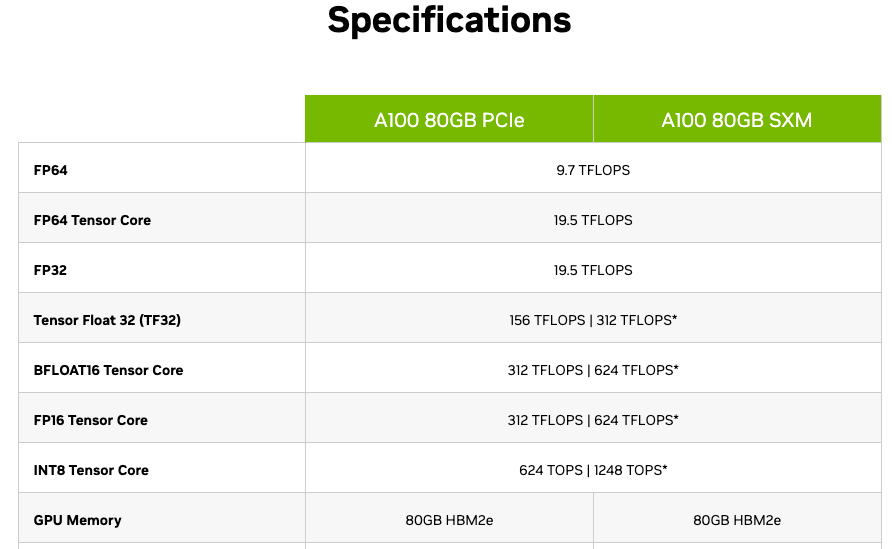

#### Llama 2 7B model GPU snapshot

computational cost (FLOPs) and memory usage (KV cache) of running inference with the LLaMA 2 7B language model for multiple users

In [70]:
def compute_attn_operations(d_k, h, seq_len):
    attn_scores = h * d_k * seq_len
    softmax = 5 * h * seq_len
    attn_v = h * d_k * seq_len
    attn_total = attn_scores + softmax + attn_v
    return attn_total

def compute_gpu_metrics_llama27b(num_users, input_tokens, output_tokens):
    # Model params
    d_model = 4096
    h = 32
    d_k = d_model // h
    d_ff = 4 * d_model
    num_layers = 32
    d_v = d_k  # for symmetry

    # === Fixed FLOPs per layer ===
    qkv_proj_flops = 3 * d_model * d_model
    output_proj_flops = d_model * d_model
    mlp_flops = 2 * d_model * d_ff
    norm_resid_flops = 4 * d_model

    fixed_flops_per_layer = qkv_proj_flops + output_proj_flops + mlp_flops + norm_resid_flops
    fixed_flops_per_token = fixed_flops_per_layer * num_layers

    # === Prompt FLOPs ===
    prompt_attention_flops = 0
    for t in range(1, input_tokens + 1):
        seq_len = t
        attn_total = compute_attn_operations(d_k, h, seq_len)
        prompt_attention_flops += attn_total * num_layers

    prompt_fixed_flops = fixed_flops_per_token * input_tokens
    prompt_total_flops = prompt_fixed_flops + prompt_attention_flops

    # === Generation FLOPs ===
    generation_attention_flops = 0
    for t in range(1, output_tokens + 1):
        seq_len = input_tokens + t - 1
        attn_total = compute_attn_operations(d_k, h, seq_len)
        generation_attention_flops += attn_total * num_layers

    generation_fixed_flops = fixed_flops_per_token * output_tokens
    generation_total_flops = generation_fixed_flops + generation_attention_flops

    total_flops_per_user = prompt_total_flops + generation_total_flops
    total_flops_all_users = total_flops_per_user * num_users
    # avg_flops_per_gen_token = generation_total_flops / output_tokens

    # === KV Cache ===
    kv_per_token_bytes = 2 * d_k * num_layers * h * 2  # 2 (K,V) * d_k * layers * heads * 2 bytes
    kv_cache_prefill = kv_per_token_bytes * input_tokens
    kv_cache_gen = kv_per_token_bytes * output_tokens
    kv_cache_total = kv_per_token_bytes * (input_tokens + output_tokens)

    def flops_fmt(flops):
        return {
            "MFLOPs": flops / 1e6,
            "GFLOPs": flops / 1e9,
            "TFLOPs": flops / 1e12
        }

    def mb(x): return x / (1024 ** 2)

    # Print Results
    print("👨🏽‍🦲💬 Per-user inference FLOPs:")
    for label, flops in [
        ("  Prompt FLOPs", prompt_total_flops),
        ("  Generation FLOPs", generation_total_flops),
        ("  Total FLOPs", total_flops_per_user),
    ]:
        formatted = flops_fmt(flops)
        print(f"{label}:   {formatted['MFLOPs']:.2f} megaFLOPs   |   {formatted['GFLOPs']:.4f} gigaFLOPs   |   {formatted['TFLOPs']:.6f} teraFLOPs")

    print(f"\n===> FLOPs for {num_users} concurrent user(s) 🧑🏽‍🦲👩🏼‍🦳")
    total_formatted = flops_fmt(total_flops_all_users)
    print(f"Total FLOPs:   {total_formatted['MFLOPs']:.2f} megaFLOPs   |   "
          f"{total_formatted['GFLOPs']:.4f} gigaFLOPs   |   {total_formatted['TFLOPs']:.6f} teraFLOPs")

    print(f"\n===> Total Memory on GPU across {num_users} users 🧑🏽‍🦲👩🏼‍🦳")
    print("KV Cache per user inference:")
    print(f"  Prefill: {mb(kv_cache_prefill):.2f} MB")
    print(f"  Generation: {mb(kv_cache_gen):.2f} MB")
    print(f"  Total: {mb(kv_cache_total):.2f} MB")

    total_kv_mb = mb(kv_cache_total * num_users)
    total_kv_gb = total_kv_mb / 1024
    print(f"\n🔘 KV Cache total for {num_users} user(s): {total_kv_mb:.2f} MB   |   {total_kv_gb:.3f} GB")
    print(f"🔘 Llama 2 🦙--7B model weights: 13-15 GB (FP16)")
    print(f"🔘 Activation (🔴🟡🟢) buffers and overheads: 8-12 GB")


#### ⭕️ 5 Users, 10 Input tokens and 100 Output tokens

In [71]:
compute_gpu_metrics_llama27b(num_users=5, input_tokens=10, output_tokens=100)

👨🏽‍🦲💬 Per-user inference FLOPs:
  Prompt FLOPs:   64444.45 megaFLOPs   |   64.4445 gigaFLOPs   |   0.064444 teraFLOPs
  Generation FLOPs:   645887.74 megaFLOPs   |   645.8877 gigaFLOPs   |   0.645888 teraFLOPs
  Total FLOPs:   710332.20 megaFLOPs   |   710.3322 gigaFLOPs   |   0.710332 teraFLOPs

===> FLOPs for 5 concurrent user(s) 🧑🏽‍🦲👩🏼‍🦳
Total FLOPs:   3551660.98 megaFLOPs   |   3551.6610 gigaFLOPs   |   3.551661 teraFLOPs

===> Total Memory on GPU across 5 users 🧑🏽‍🦲👩🏼‍🦳
KV Cache per user inference:
  Prefill: 5.00 MB
  Generation: 50.00 MB
  Total: 55.00 MB

🔘 KV Cache total for 5 user(s): 275.00 MB   |   0.269 GB
🔘 Llama 2 🦙--7B model weights: 13-15 GB (FP16)
🔘 Activation (🔴🟡🟢) buffers and overheads: 8-12 GB


#### ⭕️ 100 Users, 500 Input tokens and 1500 Output tokens

In [72]:
compute_gpu_metrics_llama27b(num_users=100, input_tokens=500, output_tokens=1500)

👨🏽‍🦲💬 Per-user inference FLOPs:
  Prompt FLOPs:   3254962.43 megaFLOPs   |   3254.9624 gigaFLOPs   |   3.254962 teraFLOPs
  Generation FLOPs:   10165382.40 megaFLOPs   |   10165.3824 gigaFLOPs   |   10.165382 teraFLOPs
  Total FLOPs:   13420344.83 megaFLOPs   |   13420.3448 gigaFLOPs   |   13.420345 teraFLOPs

===> FLOPs for 100 concurrent user(s) 🧑🏽‍🦲👩🏼‍🦳
Total FLOPs:   1342034483.20 megaFLOPs   |   1342034.4832 gigaFLOPs   |   1342.034483 teraFLOPs

===> Total Memory on GPU across 100 users 🧑🏽‍🦲👩🏼‍🦳
KV Cache per user inference:
  Prefill: 250.00 MB
  Generation: 750.00 MB
  Total: 1000.00 MB

🔘 KV Cache total for 100 user(s): 100000.00 MB   |   97.656 GB
🔘 Llama 2 🦙--7B model weights: 13-15 GB (FP16)
🔘 Activation (🔴🟡🟢) buffers and overheads: 8-12 GB


🛑 A single NVIDIA A100 can no longer handle the inference load for these 100 users...


<hr />

## Inference Optimization

> ⚠️ [note] the flow of this notebook is more on understanding the inference pipeline using an example of decoder transformer model like LLaMA 2, and appreciating the memory and computation requirements demanding the need for optimization. I will write down each optimization techniques in seperate notebooks later, and link them here...

Optimization could be for performance, cost, constraints etc... Need to double click on all of the below techniques or tools...

#### **Attention Mechanism Optimizations**

* **FlashAttention**: Optimized attention computation (low memory, fused kernels).
* **Multi-Query Attention (MQA)**
* **Grouped-Query Attention (GQA)**: Intermediate between MQA and full multi-head.
* **Key-Value (KV) Cache with Paging**: For efficient reuse and memory swapping during autoregressive generation.
* **Sliding Window Attention / Local Attention**

#### **Model Compression**
* **Quantization**:
  * Post-training quantization
  * Quantization-aware training (QAT)
  * 8-bit, 4-bit (e.g., GPTQ, AWQ)
* **Pruning / Sparsity**:
  * Structured (e.g., block sparsity)
  * Unstructured (weight-level)
  * Mixture-of-Experts (MoE) sparsity
* **Distillation**:
  * Student-teacher training to get smaller, faster model

#### **Model Architecture Optimizations**
* **Efficient Transformer Variants**:
  * Linformer, Performer, Reformer, Longformer
* [**Low-Rank Adaptation (LoRA)**](https://n03an.me/training/PEFT.html)
* **Mixture-of-Experts (MoE)**
* **Prefix Tuning / Adapters**: Lightweight inference-time adaptation.

#### **System-Level / Serving Optimization**
* **Batching**:
  * Static and dynamic batching
  * Micro-batching
* **In-flight Batching**: Dynamically merge requests at runtime.
* **Efficient Scheduling**
  * Prioritization of fast vs. long-running requests
  * Fair queueing
* **Speculative Decoding / Inference**
  * Generate multiple tokens speculatively, verify later
  * Techniques: Medusa, speculative sampling
* **Memory Management**
  * GPU memory reuse, offloading, memory pools
* **Kernel Fusion**: Fusing ops (e.g., bias+GELU) to reduce kernel launch overhead.
* **Quantization-aware Scheduling**: Matching model quant level to hardware.

#### Additional Exploration...
* **TensorRT / ONNX / TVM / XLA**: Graph compilation and kernel fusion.
* **FP16 / BF16 / INT4 runtimes**: Use of mixed precision for faster compute.
* **Offloading to CPU or disk** (paging KV cache).
* **Token Dropping / Early Exit**: Skip tokens or exit early in networks if confidence is high.
* **Dynamic Sparsity / Activation Pruning**: Zero out unimportant activations on-the-fly.
* **Prompt Compression** / Prompt Caching: Compress or cache embeddings of repeated prompts (especially useful in chat models).





